In [1]:
import pandas as pd
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import Ridge

# load dataset
data = load_diabetes( )
X, y = data.data, data.target

# convert into DataFrame for clarity
df = pd.DataFrame(X, columns = data.feature_names)
df['target'] = y

# split the dataset
X_train, X_test, y_train, y_test = train_test_split(X, y,
								   test_size = 0.2, random_state = 42)

# initialize and apply scaler
scaler = StandardScaler( )
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# train Linear Regression
linear_model = LinearRegression( )
linear_model.fit(X_train_scaled, y_train)

# evaluate the model
y_pred_linear = linear_model.predict(X_test_scaled)
mse_linear = mean_squared_error(y_test, y_pred_linear)
print("Vanilla Linear Regression (Scaled Features)")
print(f"MSE: {mse_linear:.2f}")

# train Ridge Regression
ridge_model = Ridge(alpha = 100)
ridge_model.fit(X_train_scaled, y_train)

# evaluate Ridge model
y_pred_ridge = ridge_model.predict(X_test_scaled)
mse_ridge = mean_squared_error(y_test, y_pred_ridge)
print("Ridge Regression (Scaled Features, alpha = 1.0)")
print(f"MSE: {mse_ridge:.2f}")


Vanilla Linear Regression (Scaled Features)
MSE: 2900.19
Ridge Regression (Scaled Features, alpha = 1.0)
MSE: 2858.22


In [2]:
weights_df = pd.DataFrame({
    'Feature': data.feature_names,
    'Linear Regression Weights': linear_model.coef_,
    'Ridge Regression Weights': ridge_model.coef_})

print(weights_df.to_string(index = False))


Feature  Linear Regression Weights  Ridge Regression Weights
    age                   1.753758                  2.093789
    sex                 -11.511809                 -8.168076
    bmi                  25.607121                 21.561936
     bp                  16.828872                 13.926917
     s1                 -44.448856                 -2.898262
     s2                  24.640954                 -4.087197
     s3                   7.676978                 -9.059339
     s4                  13.138784                  6.683867
     s5                  35.161195                 16.477222
     s6                   2.351364                  4.688816


In [3]:
coefs = []

for i in [0,10,100,1000]:
    reg = Ridge(alpha=i)
    reg.fit(X_train_scaled,y_train)

    coefs.append(reg.coef_.tolist())

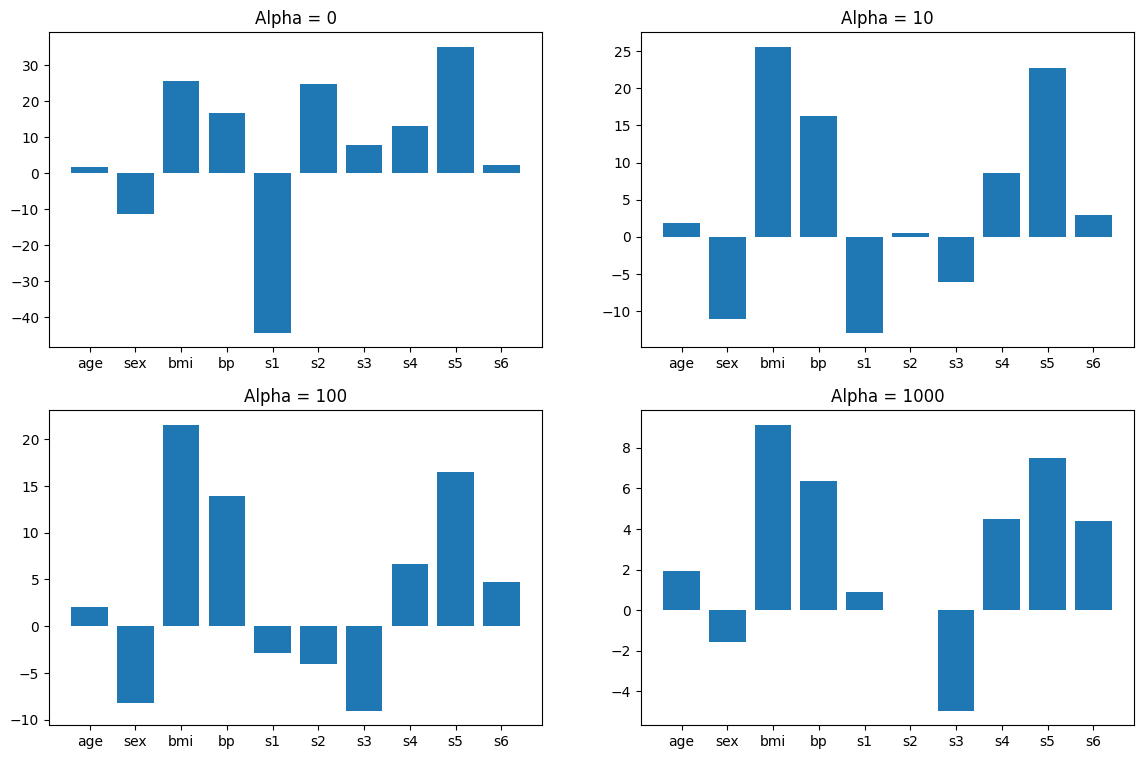

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,9))
plt.subplot(221)
plt.bar(data.feature_names,coefs[0])
plt.title('Alpha = 0')

plt.subplot(222)
plt.bar(data.feature_names,coefs[1])
plt.title('Alpha = 10')

plt.subplot(223)
plt.bar(data.feature_names,coefs[2])
plt.title('Alpha = 100')

plt.subplot(224)
plt.bar(data.feature_names,coefs[3])
plt.title('Alpha = 1000')

plt.show()

In [5]:
alphas = [0,0.0001,0.0005,0.001,0.005,0.1,0.5,1,5,10]

coefs = []

for i in alphas:
    reg = Ridge(alpha=i)
    reg.fit(X_train_scaled,y_train)

    coefs.append(reg.coef_.tolist())

In [7]:
import numpy as np
input_array = np.array(coefs).T

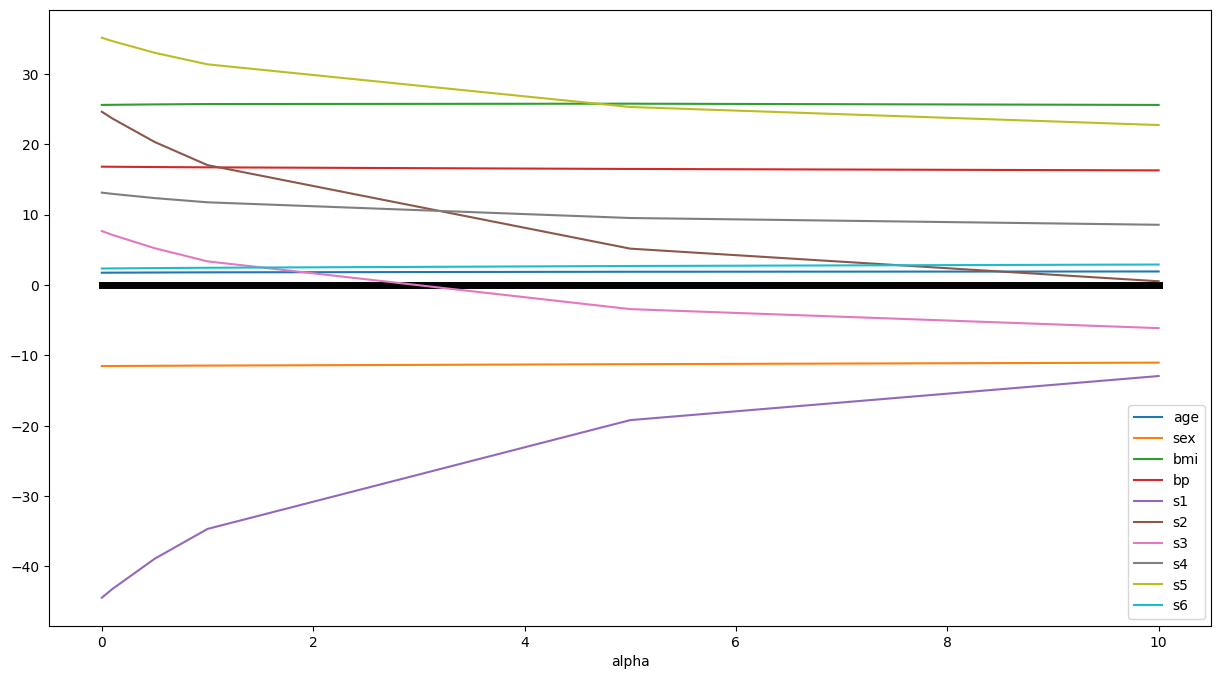

In [8]:
plt.figure(figsize=(15,8))
plt.plot(alphas,np.zeros(len(alphas)),color='black',linewidth=5)
for i in range(input_array.shape[0]):
    plt.plot(alphas,input_array[i],label=data.feature_names[i])
plt.xlabel('alpha')
plt.legend()

In [9]:
from mlxtend.evaluate import bias_variance_decomp

alphas = np.linspace(0,30,100)

loss = []
bias = []
variance = []

for i in alphas:
    reg = Ridge(alpha=i)
    avg_expected_loss, avg_bias, avg_var = bias_variance_decomp(
        reg, X_train_scaled, y_train, X_test_scaled, y_test,
        loss='mse',
        random_seed=123)
    loss.append(avg_expected_loss)
    bias.append(avg_bias)
    variance.append(avg_var)

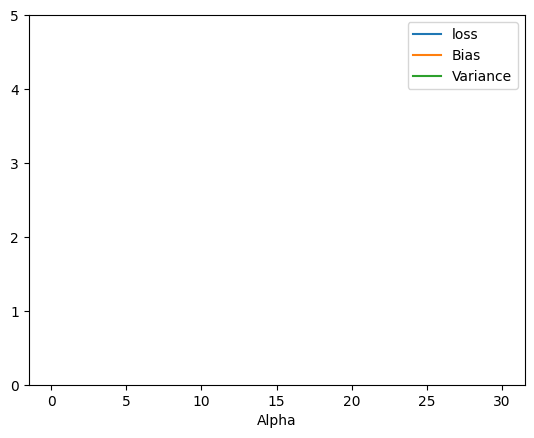

In [11]:
plt.plot(alphas,loss,label='loss')
plt.plot(alphas,bias,label='Bias')
plt.plot(alphas,variance,label='Variance')
plt.ylim(0,5)
plt.xlabel('Alpha')
plt.legend()
plt.show()

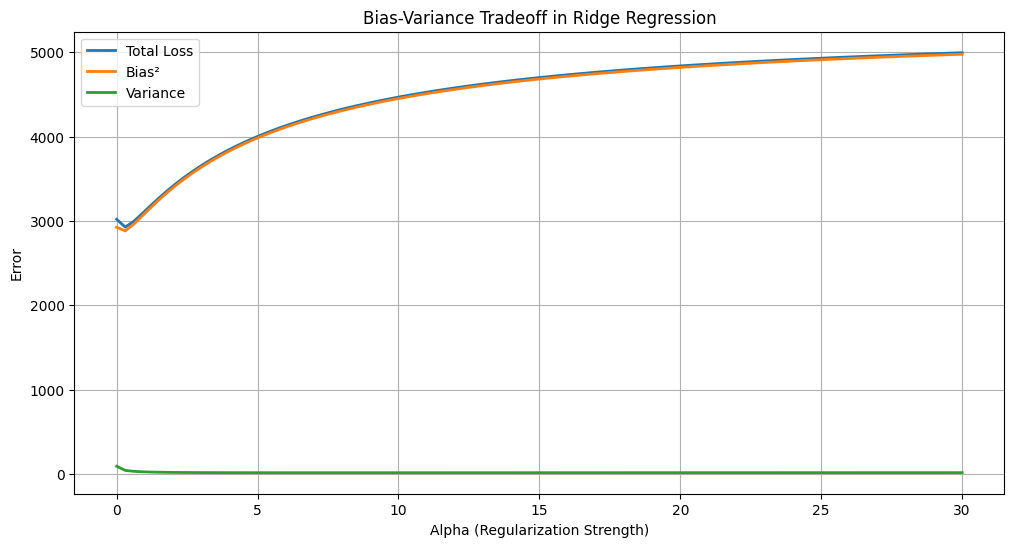

In [12]:
# Step 1: Install mlxtend if not already installed
!pip install mlxtend

# Step 2: Import libraries
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from mlxtend.evaluate import bias_variance_decomp

# Step 3: Load and split the data
data = load_diabetes()
X, y = data.data, data.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# Step 4: Standardize the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Step 5: Set up Ridge regression with varying alpha
alphas = np.linspace(0, 30, 100)
loss, bias, variance = [], [], []

# Step 6: Evaluate bias-variance decomposition for each alpha
for alpha in alphas:
    reg = Ridge(alpha=alpha)
    avg_loss, avg_bias, avg_var = bias_variance_decomp(
        reg, X_train, y_train, X_test, y_test,
        loss='mse',
        random_seed=123
    )
    loss.append(avg_loss)
    bias.append(avg_bias)
    variance.append(avg_var)

# Step 7: Plot the results
plt.figure(figsize=(12, 6))
plt.plot(alphas, loss, label='Total Loss', linewidth=2)
plt.plot(alphas, bias, label='Bias²', linewidth=2)
plt.plot(alphas, variance, label='Variance', linewidth=2)
plt.xlabel('Alpha (Regularization Strength)')
plt.ylabel('Error')
plt.title('Bias-Variance Tradeoff in Ridge Regression')
plt.legend()
plt.grid(True)
plt.show()

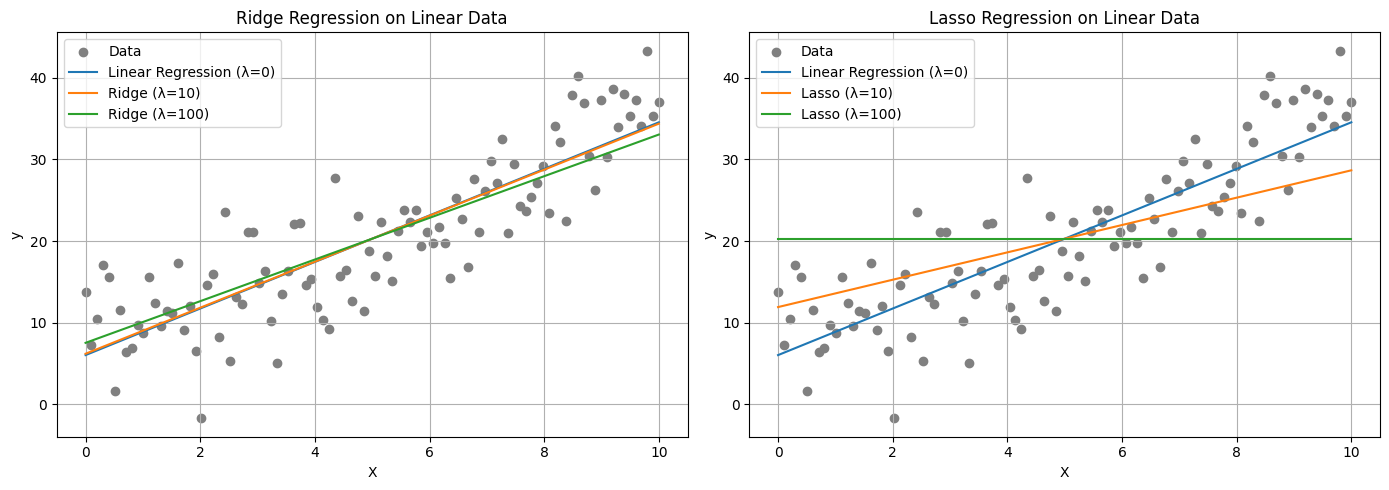

In [13]:
# Enable inline plotting in Colab (optional)
%matplotlib inline

# Import libraries
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge, Lasso, LinearRegression

# Generate synthetic linear data
np.random.seed(0)
X_linear = np.linspace(0, 10, 100).reshape(-1, 1)
y_linear = 3 * X_linear.flatten() + 5 + np.random.randn(100) * 5  # Linear with noise

# Define alpha values
alphas = [0, 10, 100]

# Set up the plots
fig, axs = plt.subplots(1, 2, figsize=(14, 5))
x_plot = np.linspace(0, 10, 100).reshape(-1, 1)

# --- Plot Ridge Regression ---
axs[0].scatter(X_linear, y_linear, color='gray', label='Data')
for alpha in alphas:
    if alpha == 0:
        model = LinearRegression()
        label = 'Linear Regression (λ=0)'
    else:
        model = Ridge(alpha=alpha)
        label = f'Ridge (λ={alpha})'
    model.fit(X_linear, y_linear)
    y_pred = model.predict(x_plot)
    axs[0].plot(x_plot, y_pred, label=label)

axs[0].set_title('Ridge Regression on Linear Data')
axs[0].set_xlabel('X')
axs[0].set_ylabel('y')
axs[0].legend()
axs[0].grid(True)

# --- Plot Lasso Regression ---
axs[1].scatter(X_linear, y_linear, color='gray', label='Data')
for alpha in alphas:
    if alpha == 0:
        model = LinearRegression()
        label = 'Linear Regression (λ=0)'
    else:
        model = Lasso(alpha=alpha)
        label = f'Lasso (λ={alpha})'
    model.fit(X_linear, y_linear)
    y_pred = model.predict(x_plot)
    axs[1].plot(x_plot, y_pred, label=label)

axs[1].set_title('Lasso Regression on Linear Data')
axs[1].set_xlabel('X')
axs[1].set_ylabel('y')
axs[1].legend()
axs[1].grid(True)

plt.tight_layout()
plt.show()


In [11]:

import pandas as pd
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import Lasso

# load dataset
data = load_diabetes( )
X, y = data.data, data.target

# convert into DataFrame for clarity
df = pd.DataFrame(X, columns = data.feature_names)
df['target'] = y

# split the dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, random_state = 42)

# initialize and apply scaler
scaler = StandardScaler( )
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# train Linear Regression
linear_model = LinearRegression( )
linear_model.fit(X_train_scaled, y_train)

# evaluate the model
y_pred_linear = linear_model.predict(X_test_scaled)
mse_linear = mean_squared_error(y_test, y_pred_linear)
print(f"Linear Regression MSE: {mse_linear:.2f}")

# train Lasso Regression with alpha = 1.0
lasso_model = Lasso(alpha = 1.0)
lasso_model.fit(X_train_scaled, y_train)

# predict and evaluate
y_pred_lasso = lasso_model.predict(X_test_scaled)
mse_lasso = mean_squared_error(y_test, y_pred_lasso)
print(f"Lasso Regression MSE: {mse_lasso:.2f}")


Linear Regression MSE: 2900.19
Lasso Regression MSE: 2824.57


In [15]:
from sklearn.datasets import load_diabetes

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.linear_model import Lasso
from sklearn.metrics import r2_score

from sklearn.model_selection import train_test_split

In [16]:
data = load_diabetes()

df = pd.DataFrame(data.data,columns=data.feature_names)
df['TARGET'] = data.target

df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,TARGET
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


In [17]:
X_train,X_test,y_train,y_test = train_test_split(data.data,data.target,test_size=0.2,random_state=2)

In [19]:
coefs = []
r2_scores = []

for i in [0,0.1,1,10]:
    reg = Lasso(alpha=i)
    reg.fit(X_train,y_train)

    coefs.append(reg.coef_.tolist())
    y_pred = reg.predict(X_test)
    r2_scores.append(r2_score(y_test,y_pred))

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: UserWarning: With alpha=0, this algorithm does not converge well. You are advised to use the LinearRegression estimator
  return fit_method(estimator, *args, **kwargs)
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: UserWarning: Coordinate descent with no regularization may lead to unexpected results and is discouraged.
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.967e+05, tolerance: 2.124e+02 Linear regression models with null weight for the l1 regularization term are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_coordinate_descent

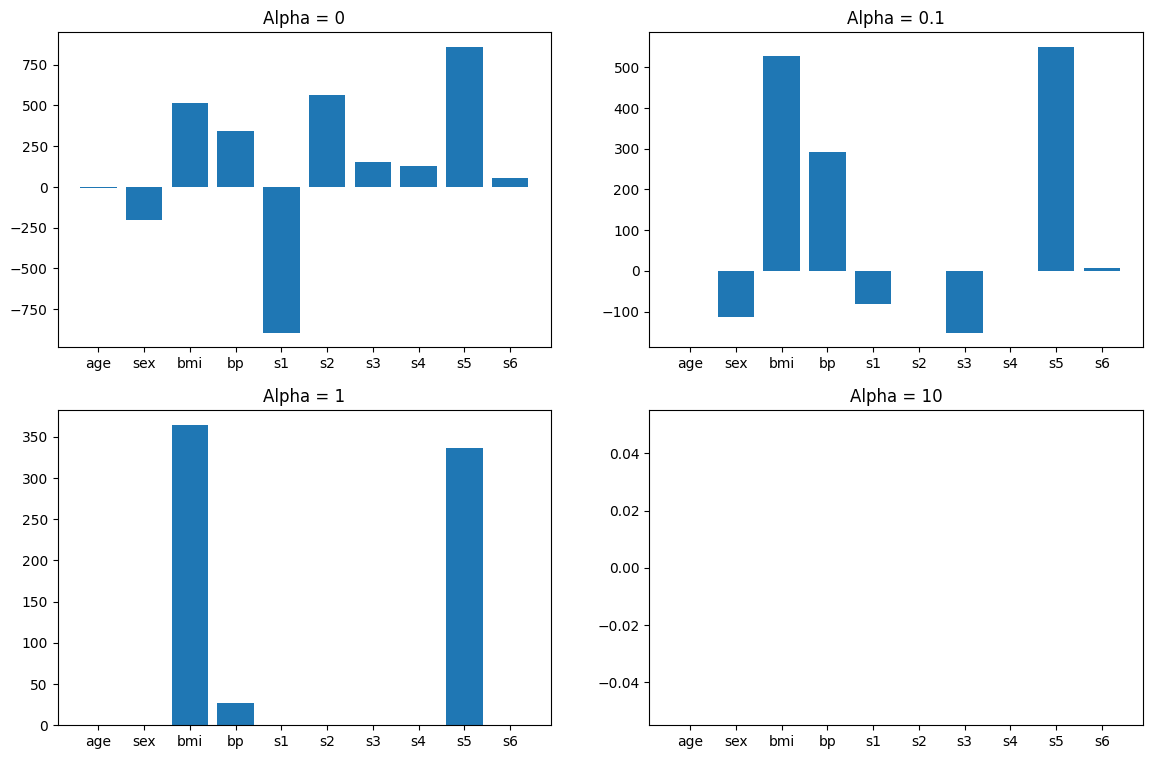

In [20]:
plt.figure(figsize=(14,9))
plt.subplot(221)
plt.bar(data.feature_names,coefs[0])
plt.title('Alpha = 0')

plt.subplot(222)
plt.bar(data.feature_names,coefs[1])
plt.title('Alpha = 0.1')

plt.subplot(223)
plt.bar(data.feature_names,coefs[2])
plt.title('Alpha = 1')

plt.subplot(224)
plt.bar(data.feature_names,coefs[3])
plt.title('Alpha = 10')

plt.show()


In [12]:
from sklearn.linear_model import ElasticNet

# train Elastic Net Regression (alpha here corresponds to lambda)
elastic_model = ElasticNet(alpha = 1, l1_ratio = 0.9)
elastic_model.fit(X_train_scaled, y_train)

# predict and evaluate
y_pred_elastic = elastic_model.predict(X_test_scaled)
mse_elastic = mean_squared_error(y_test, y_pred_elastic)
print(f"Elastic MSE: {mse_elastic:.2f}")


Elastic MSE: 2822.31
